# Indonesian Lip Reading (IndoLR) — LRCN Pipeline Colab Version

Notebook ini dibuat berdasarkan kebutuhan untuk dijalankan di dalam env google colab dan untuk menjalankannya secara offline butuh beberapa penyesuaian seperti pada bagian backup (hanya dibutuhkan saat memakai colab karena harus mengganti runtime)

**Alur kerja :**

1. **Bagian 1 (Setup & Download Data)** — jalankan di runtime apa saja (CPU cukup).
2. **Bagian 2 (Preprocessing / Lip ROI Extraction)** — **WAJIB pakai runtime CPU**. 
3. **Ganti runtime ke GPU (T4)** lewat menu `Runtime > Change runtime type > GPU`.
4. **Bagian 3 (Load Data + Model + Training)** — jalankan dengan **runtime GPU**.
5. **Bagian 4 (Evaluasi)** — precision/recall/F1/confusion matrix pada test set.
6. **Bagian 5 (Inference Demo)** — coba prediksi 1 video baru + text-to-speech.

Semua konfigurasi penting (path, ukuran gambar, panjang sequence, dsb) dikumpulkan di satu sel `CONFIG` di Bagian 1 supaya mudah diubah tanpa harus mengubah banyak sel.

## Bagian 1 — Setup, Konfigurasi, dan Download Dataset

*(Runtime: CPU cukup)*

In [ ]:
# @title 1.1 CONFIG — ubah path/parameter di sini saja
import os

CONFIG = {
    # --- Path ---
    "ROOT_VIDEO": "/content/data",                       # video mentah hasil download kaggle
    "OUT_ROOT": "/content/precomputed",                  # hasil preprocessing (lokal, sementara)
    "DRIVE_BACKUP_DIR": "/content/drive/MyDrive/IndoLR/precomputed",  # backup permanen di Drive
    "MODEL_TASK_PATH": "/content/face_landmarker.task",

    # --- Preprocessing ---
    "SEQ_LEN_WORD": 30,       # sesuai jurnal: 30 frame untuk dataset kata
    "SEQ_LEN_PHRASE": 40,     # sesuai jurnal: 40 frame untuk dataset frasa
    "TARGET_SIZE": (80, 80),  # sesuai jurnal: 80x80
    "MAX_FRAMES_READ": 400,
    "PAD_RATIO": 0.15,
    "MIN_BOX_SIZE": 20,
    "MAX_WORD_INDEX": 11,     # folder kata "1 Maaf" ... "10 Awas" (indeks <= 11 -> word dataset)

    # --- Training ---
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 1e-3,
    "EPOCHS": 80,
    "PATIENCE": 8,            # early stopping
    "SEED": 27,
    "USE_WANDB": True,        # aktif by default -- integrasi wandb untuk tracking per-kelas
    "PREPROCESS_VERSION": "bbox_v2_mouth_center_no_extra_pad",  # PENTING: catat versi formula bbox
                              # supaya kalau nanti dipakai ulang di script lain (mobile/live-inference),
                              # formula bisa dicocokkan lewat metadata checkpoint, bukan ditebak/disalin manual.
}

os.makedirs(CONFIG["OUT_ROOT"], exist_ok=True)
os.makedirs(CONFIG["DRIVE_BACKUP_DIR"], exist_ok=True)
print("Konfigurasi siap.")
for k, v in CONFIG.items():
    print(f"  {k}: {v}")

Konfigurasi siap.
  ROOT_VIDEO: /content/data
  OUT_ROOT: /content/precomputed
  DRIVE_BACKUP_DIR: /content/drive/MyDrive/IndoLR/precomputed
  MODEL_TASK_PATH: /content/face_landmarker.task
  SEQ_LEN_WORD: 30
  SEQ_LEN_PHRASE: 40
  TARGET_SIZE: (80, 80)
  MAX_FRAMES_READ: 400
  PAD_RATIO: 0.15
  MIN_BOX_SIZE: 20
  MAX_WORD_INDEX: 11
  BATCH_SIZE: 16
  LEARNING_RATE: 0.001
  EPOCHS: 80
  PATIENCE: 8
  SEED: 27
  USE_WANDB: True
  PREPROCESS_VERSION: bbox_v2_mouth_center_no_extra_pad


In [ ]:
# @title 1.2 Download dataset IndoLR dari Kaggle
!pip install -q kagglehub

In [ ]:
# @title 1.3 Download dataset IndoLR dari Kaggle
import kagglehub

kaggle_path = kagglehub.dataset_download("abasset/indolr")
print("Dataset terunduh di:", kaggle_path)

100%|██████████| 4.26G/4.26G [00:50<00:00, 90.9MB/s]

Extracting files...


Dataset terunduh di: /root/.cache/kagglehub/datasets/abasset/indolr/versions/1


In [ ]:
# @title 1.4 Salin data video ke /content/data (working dir)
import shutil, glob

os.makedirs(CONFIG["ROOT_VIDEO"], exist_ok=True)

# Salin seluruh isi dataset (folder per orang -> folder per kata/frasa -> video .mp4)
# Menggunakan dirs_exist_ok=True supaya aman dijalankan ulang tanpa error.
shutil.copytree(kaggle_path, CONFIG["ROOT_VIDEO"], dirs_exist_ok=True)

n_videos = len(glob.glob(os.path.join(CONFIG["ROOT_VIDEO"], "**", "*.mp4"), recursive=True))
print(f"Total video ditemukan: {n_videos}")

Total video ditemukan: 5807


In [ ]:
#mengatasi format yang error pada file data.
!mv "/content/data/8 Glamor ( Bella )/8 Glamor ( Bella ) - Copy - Copy/"* "/content/data/8 Glamor ( Bella )/"

In [ ]:
# @title 1.5 Download model MediaPipe Face Landmarker
!wget -O {CONFIG['MODEL_TASK_PATH']} -q https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/1/face_landmarker.task
print("Model landmarker tersimpan di:", CONFIG['MODEL_TASK_PATH'])

Model landmarker tersimpan di: /content/face_landmarker.task


In [ ]:
# @title 1.6 Install dependencies
!pip install -q mediapipe opencv-python-headless gTTS scikit-learn imageio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 101.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.4/137.4 kB 13.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.2/98.2 kB 8.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
huggingface-hub 1.23.0 requires click<9.0.0,>=8.4.2, but you have click 8.1.8 which is incompatible.
wandb 0.28.0 requires click>=8.2.0, but you have click 8.1.8 which is incompatible.


In [ ]:
import mediapipe as mp
print(mp.__version__)
try:
    from mediapipe.solutions import face_mesh
    print("mp.solutions.face_mesh TERSEDIA")
    print(len(face_mesh.FACEMESH_LIPS), "koneksi ditemukan")
except (ImportError, AttributeError) as e:
    print("mp.solutions.face_mesh TIDAK TERSEDIA:", e)

0.10.35
mp.solutions.face_mesh TIDAK TERSEDIA: No module named 'mediapipe.solutions'


## Bagian 2 — Preprocessing (Lip ROI Extraction)

### ⚠️ WAJIB jalankan bagian ini dengan runtime CPU
`Runtime > Change runtime type > CPU`

Metode yang dipakai di sini adalah **metode bounding-box dinamis berbasis titik tengah bibir** (versi terbaik dari 2 metode yang ada di prototipe asli — metode ini lebih stabil karena bounding box mengikuti pusat bibir, bukan cuma sisi terluar sehingga bagian bibir atas jarang terpotong).

Langkah preprocessing mengikuti Section 3.2 jurnal:
1. Deteksi 468 landmark wajah dengan MediaPipe Face Mesh (di sini pakai FaceLandmarker task API).
2. Ambil landmark bibir (outer + inner lips), hitung bounding box dinamis di sekitar titik tengah bibir.
3. Crop, padding jadi persegi (supaya tidak distorsi saat di-resize), lalu resize ke 80x80 dan ubah ke grayscale.
4. Sequence dipotong/diberi padding hitam di TENGAH (bukan dari frame ke-0) supaya fokus ke saat bibir bergerak.
5. Normalisasi pixel ke rentang 0–1.

In [ ]:
# @title 2.1 Import & inisialisasi MediaPipe FaceLandmarker
import os, glob, re
import cv2
import numpy as np
from pathlib import Path
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision as mp_vision

base_options = mp_python.BaseOptions(model_asset_path=CONFIG["MODEL_TASK_PATH"])
landmarker_options = mp_vision.FaceLandmarkerOptions(
    base_options=base_options,
    num_faces=1,
    output_face_blendshapes=False,
    output_facial_transformation_matrixes=False,
)
detector = mp_vision.FaceLandmarker.create_from_options(landmarker_options)

# Landmark index bibir (outer + inner lips) dari MediaPipe Face Mesh.
# PENTING: set ini sekarang PERSIS sama dengan konstanta resmi
# mediapipe.solutions.face_mesh.FACEMESH_LIPS (40 koneksi, 4 cincin:
# outer-lower, outer-upper, inner-lower, inner-upper). Versi sebelumnya HANYA
# berisi ring lower (22 koneksi) sehingga titik-titik puncak bibir atas
# (index 0, 13, 37, 39, 40, 80, 81, 82, 185, 191, 267, 269, 270, 310, 311,
# 312, 409, 415) tidak pernah ikut dihitung -> bounding box jadi terlalu
# pendek di sisi atas -> bibir atas kepotong di hasil crop.
LIPS_PAIRS = [
    # outer lips - lower ring
    (61, 146), (146, 91), (91, 181), (181, 84), (84, 17), (17, 314),
    (314, 405), (405, 321), (321, 375), (375, 291),
    # outer lips - upper ring
    (61, 185), (185, 40), (40, 39), (39, 37), (37, 0),
    (0, 267), (267, 269), (269, 270), (270, 409), (409, 291),
    # inner lips - lower ring
    (78, 95), (95, 88), (88, 178), (178, 87), (87, 14), (14, 317),
    (317, 402), (402, 318), (318, 324), (324, 308),
    # inner lips - upper ring
    (78, 191), (191, 80), (80, 81), (81, 82), (82, 13),
    (13, 312), (312, 311), (311, 310), (310, 415), (415, 308),
]

def _unique_indices_from_pairs(pairs):
    seen = []
    for a, b in pairs:
        if a not in seen: seen.append(a)
        if b not in seen: seen.append(b)
    return seen

LIPS_IDX = sorted(_unique_indices_from_pairs(LIPS_PAIRS))
print(f"Jumlah landmark bibir yang dipakai: {len(LIPS_IDX)}")  # sebelumnya 22, sekarang harusnya 40

Jumlah landmark bibir yang dipakai: 40


In [ ]:
# @title 2.2 Fungsi-fungsi preprocessing (deteksi, crop, resize, padding sequence)
TARGET_SIZE = CONFIG["TARGET_SIZE"]
PAD_RATIO = CONFIG["PAD_RATIO"]
MIN_BOX_SIZE = CONFIG["MIN_BOX_SIZE"]
MAX_FRAMES_READ = CONFIG["MAX_FRAMES_READ"]

def extract_mouth_points(landmarks, w, h):
    pts = []
    for idx in LIPS_IDX:
        lm = landmarks[idx]
        pts.append((int(lm.x * w), int(lm.y * h)))
    return pts

def mouth_center_from_points(pts):
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    return int(np.mean(xs)), int(np.mean(ys))

def bbox_from_mouth_center(center, pts, w, h):
    """Bounding box dari MIN/MAX koordinat landmark bibir langsung (bukan dari
    lebar mulut dikali rasio tetap) -- sesuai getBoundary() pada kode referensi
    Aripin & Setiawan (resMax/resMin dari 'routes'), sehingga box selalu pas
    mengikuti bentuk bibir dan TIDAK ikut menangkap hidung/kumis/dagu.

    Parameter 'center' dipertahankan di signature untuk kompatibilitas
    pemanggilan, tapi tidak lagi dipakai untuk menghitung box.
    """
    xs = [p[0] for p in pts]
    ys = [p[1] for p in pts]
    x_min, x_max = min(xs), max(xs)
    y_min, y_max = min(ys), max(ys)

    box_w = x_max - x_min
    box_h = y_max - y_min

    # Padding kecil & proporsional terhadap ukuran bibir itu sendiri
    # (bukan terhadap lebar mulut seperti sebelumnya), sekadar memberi
    # sedikit ruang tepi supaya bibir tidak terpotong persis di garis.
    pad_w = int(box_w * PAD_RATIO)
    pad_h = int(box_h * PAD_RATIO)

    x1 = max(0, x_min - pad_w)
    y1 = max(0, y_min - pad_h)
    x2 = min(w, x_max + pad_w)
    y2 = min(h, y_max + pad_h)

    if (x2 - x1) < MIN_BOX_SIZE or (y2 - y1) < MIN_BOX_SIZE:
        return None
    return x1, y1, x2, y2

def crop_and_resize(img, bbox):
    x1, y1, x2, y2 = bbox
    crop = img[y1:y2, x1:x2]
    if crop.size == 0: return None

    # Padding jadi persegi supaya tidak distorsi ketika di-resize ke TARGET_SIZE
    h, w = crop.shape[:2]
    side = max(h, w)
    canvas = np.zeros((side, side, 3), dtype=np.uint8)
    yoff, xoff = (side - h) // 2, (side - w) // 2
    canvas[yoff:yoff+h, xoff:xoff+w] = crop

    return cv2.resize(canvas, TARGET_SIZE, interpolation=cv2.INTER_AREA)

def center_pad_sequence(frames, seq_len):
    """Sesuai Section 3.2 jurnal & Figure 3 (halaman 6):

    Kasus 1 - jumlah frame LEBIH BANYAK dari seq_len:
        Ambil potongan dari TENGAH sequence secara simetris (buang bagian awal
        dan akhir yang cenderung diam/stillness). Contoh pada Figure 3 (atas):
        actual index 0..39 (40 frame) -> selected index kira-kira 6..34 (tengah).

    Kasus 2 - jumlah frame LEBIH SEDIKIT dari seq_len (speaker bicara terlalu cepat):
        Frame asli TETAP DIPERTAHANKAN UTUH DI AWAL, lalu black-padding
        ditambahkan HANYA DI AKHIR (bukan displit ke kiri & kanan). Ini sesuai
        Figure 3 (bawah):
            Actual Frame Index:   0 1 2 3 4 .... 23 24
            Selected Frame Index: 0 1 2 3 4 .... 23 24 25 26 27 28 29
        yaitu index 0-24 adalah frame asli, index 25-29 adalah black-padding
        yang ditambahkan di ekor sequence.
    """
    n = len(frames)
    black = np.zeros((TARGET_SIZE[1], TARGET_SIZE[0]), dtype=np.uint8)

    if n == 0:
        frames = [black] * seq_len
    elif n >= seq_len:
        # Kasus 1: potong simetris dari tengah
        s = (n - seq_len) // 2
        frames = frames[s:s+seq_len]
    else:
        # Kasus 2: black-padding HANYA di akhir (sesuai Figure 3 bawah)
        frames = frames + [black] * (seq_len - n)

    out = []
    for f in frames:
        if f.ndim == 3:
            f = cv2.cvtColor(f, cv2.COLOR_BGR2GRAY)
        out.append(cv2.resize(f, TARGET_SIZE))

    return (np.stack(out).astype(np.float32) / 255.0)

def process_video(video_path, seq_len):
    cap = cv2.VideoCapture(video_path)
    frames_roi = []
    last_roi = None
    total, success = 0, 0

    while cap.isOpened() and total < MAX_FRAMES_READ:
        ret, frame = cap.read()
        if not ret: break
        total += 1

        roi = last_roi
        try:
            mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))
            result = detector.detect(mp_img)

            if result.face_landmarks:
                landmarks = result.face_landmarks[0]
                h, w = frame.shape[:2]
                pts = extract_mouth_points(landmarks, w, h)
                center = mouth_center_from_points(pts)
                bbox = bbox_from_mouth_center(center, pts, w, h)
                if bbox:
                    cropped = crop_and_resize(frame, bbox)
                    if cropped is not None:
                        roi = cropped
                        last_roi = cropped
                        success += 1
        except Exception:
            pass

        if roi is not None:
            frames_roi.append(roi)

    cap.release()
    ratio = success / max(total, 1)
    return center_pad_sequence(frames_roi, seq_len), total, success, ratio

In [ ]:
# @title 2.3 Jalankan preprocessing untuk seluruh dataset (word + phrase)
def extract_leading_number(name):
    m = re.match(r'^\(?\s*(\d+)', name.strip())
    return int(m.group(1)) if m else None

def sanitize_name(name):
    """Bersihkan nama folder orang supaya aman dipakai sebagai bagian nama file."""
    return re.sub(r'[^A-Za-z0-9_-]+', '_', name.strip())

def run_preprocessing():
    os.makedirs(CONFIG["OUT_ROOT"], exist_ok=True)
    log = []

    for person in sorted(os.listdir(CONFIG["ROOT_VIDEO"])):
        p_path = os.path.join(CONFIG["ROOT_VIDEO"], person)
        if not os.path.isdir(p_path): continue

        safe_person = sanitize_name(person)

        for keyword in sorted(os.listdir(p_path)):
            kw_path = os.path.join(p_path, keyword)
            if not os.path.isdir(kw_path): continue

            num = extract_leading_number(keyword)
            if num is None: continue

            seq_len = CONFIG["SEQ_LEN_WORD"] if num <= CONFIG["MAX_WORD_INDEX"] else CONFIG["SEQ_LEN_PHRASE"]

            out_kw = os.path.join(CONFIG["OUT_ROOT"], keyword)
            Path(out_kw).mkdir(parents=True, exist_ok=True)

            print(f"\n▶ {keyword}  [{person}]  (seq_len={seq_len})")

            for f in glob.glob(os.path.join(kw_path, "*.mp4")):
                # PENTING: prefix nama speaker ditambahkan di sini supaya nama file
                # TIDAK tabrakan antar-orang (sebelumnya "data (1).npy" dari orang A
                # dan orang B sama persis -> orang B otomatis ter-skip diam-diam
                # oleh pengecekan `if os.path.exists(out_path): continue` di bawah,
                # sehingga sebagian besar speaker hilang dari dataset training).
                out_name = f"{safe_person}__{Path(f).stem}.npy"
                out_path = os.path.join(out_kw, out_name)
                if os.path.exists(out_path): continue  # skip yang sudah pernah diproses
                try:
                    arr, total, success, ratio = process_video(f, seq_len)
                    np.save(out_path, arr)
                    log.append((f, total, success, ratio))
                    print(f"  ✓ {Path(f).name}: frames={total}, valid_roi={success}, ratio={ratio:.2f}")
                except Exception as e:
                    print(f"  ❌ Skip {f}: {e}")
    return log

preprocessing_log = run_preprocessing()
print(f"\nSelesai. {len(preprocessing_log)} video diproses.")

Output streaming akan dipotong hingga 5000 baris terakhir.
▶ 14 Minta Tolong  [2 Pointy Natural ( Sandy )]  (seq_len=40)
  ✓ WIN_20240102_17_41_03_Pro.mp4: frames=68, valid_roi=68, ratio=1.00
  ✓ WIN_20240102_17_43_53_Pro.mp4: frames=79, valid_roi=79, ratio=1.00
  ✓ WIN_20240102_17_43_49_Pro.mp4: frames=58, valid_roi=58, ratio=1.00
  ✓ WIN_20240102_17_40_43_Pro.mp4: frames=60, valid_roi=60, ratio=1.00
  ✓ WIN_20240102_17_45_22_Pro.mp4: frames=73, valid_roi=73, ratio=1.00
  ✓ WIN_20240102_17_42_38_Pro.mp4: frames=78, valid_roi=78, ratio=1.00
  ✓ WIN_20240102_17_44_44_Pro.mp4: frames=73, valid_roi=73, ratio=1.00
  ✓ WIN_20240102_17_43_59_Pro.mp4: frames=78, valid_roi=78, ratio=1.00
  ✓ WIN_20240102_17_41_43_Pro.mp4: frames=79, valid_roi=79, ratio=1.00
  ✓ WIN_20240102_17_45_27_Pro.mp4: frames=79, valid_roi=79, ratio=1.00
  ✓ WIN_20240102_17_44_40_Pro.mp4: frames=72, valid_roi=72, ratio=1.00
  ✓ WIN_20240102_17_44_15_Pro.mp4: frames=69, valid_roi=69, ratio=1.00
  ✓ WIN_20240102_17_40_32_P

In [ ]:
# @title 2.4 Validasi cepat hasil .npy (opsional tapi disarankan)
import random

sample_files = glob.glob(os.path.join(CONFIG["OUT_ROOT"], "**", "*.npy"), recursive=True)
print(f"Total file .npy: {len(sample_files)}")

if sample_files:
    check_file = random.choice(sample_files)
    arr = np.load(check_file)
    print("Contoh file:", check_file)
    print("Shape:", arr.shape, "| dtype:", arr.dtype, "| range:", arr.min(), "-", arr.max())
    assert arr.shape[1:] == CONFIG["TARGET_SIZE"], "Ukuran frame tidak sesuai TARGET_SIZE!"

Total file .npy: 5807
Contoh file: /content/precomputed/3 Permisi/8_Glamor_Bella___WIN_20240112_13_56_59_Pro.npy
Shape: (30, 80, 80) | dtype: float32 | range: 0.0 - 0.5764706


In [ ]:
# @title 2.5 Backup hasil preprocessing ke Google Drive (WAJIB sebelum ganti runtime!)
# Ganti runtime CPU -> GPU akan menghapus semua isi /content, jadi file .npy HARUS
# disalin ke Drive dulu. Sel ini pakai `cp -r` (bukan zip) supaya bisa di-resume
# (rsync-like) kalau notebook terputus di tengah jalan.
!cp -r -n {CONFIG["OUT_ROOT"]}/* {CONFIG["DRIVE_BACKUP_DIR"]}/
print("Backup selesai ke:", CONFIG["DRIVE_BACKUP_DIR"])
print("Sekarang silakan ganti runtime: Runtime > Change runtime type > GPU (T4), lalu lanjut ke Bagian 3.")

cp: target '/content/drive/MyDrive/IndoLR/precomputed/' is not a directory
Backup selesai ke: /content/drive/MyDrive/IndoLR/precomputed
Sekarang silakan ganti runtime: Runtime > Change runtime type > GPU (T4), lalu lanjut ke Bagian 3.


In [ ]:
import os
import json

# =====================================================================
# 1. TEMPEL KODE KAGGLE API TOKEN
# =====================================================================
os.environ['KAGGLE_API_TOKEN'] = "KGAT_6afe5515d17bd82946b81ff3775e4e69"

# Masukkan username asli Kaggle kamu di sini (Bisa dilihat di profil Kaggle-mu)
USERNAME_KAGGLE = "afnanimadurrosyad"

print("✓ Token dan Username berhasil dikonfigurasi!")
print("-" * 60)

# =====================================================================
# 2. ZIP DATASET AGAR TIDAK DI-SKIP
# =====================================================================
# Membuat folder penampung final untuk file zip & metadata
UPLOAD_DIR = "/content/kaggle_upload_ready"
os.makedirs(UPLOAD_DIR, exist_ok=True)

print("Sedang mengompres dataset menjadi file ZIP (biar folder gak di-skip)...")
# Mengompres semua isi dari OUT_ROOT langsung ke file zip di folder upload
!zip -r -q {UPLOAD_DIR}/dataset_siap_train.zip {CONFIG["OUT_ROOT"]}/*
print("✓ Kompresi selesai!")
print("-" * 60)

# =====================================================================
# 3. KREASI METADATA YANG VALID
# =====================================================================
!kaggle datasets init -p {UPLOAD_DIR}

metadata_path = os.path.join(UPLOAD_DIR, "dataset-metadata.json")
JUDUL_DATASET = "lipreadingv3"  # Judul dataset di Kaggle

with open(metadata_path, 'r') as f:
    meta = json.load(f)

# Menggunakan username aslimu agar tidak error Invalid Owner Id
meta['id'] = f"{USERNAME_KAGGLE}/{JUDUL_DATASET.lower()}"
meta['title'] = JUDUL_DATASET

with open(metadata_path, 'w') as f:
    json.dump(meta, f, indent=2)

print("✓ Metadata berhasil diperbaiki dengan Owner ID yang valid.")
print("-" * 60)

# =====================================================================
# 4. TERBANGKAN DATA KE KAGGLE
# =====================================================================
print("Memulai ulang transfer langsung ke Kaggle (Cloud-to-Cloud)...")
!kaggle datasets create -p {UPLOAD_DIR}

print("\n" + "="*60)
print("SELESAI! Cek akun Kaggle-mu pada bagian Datasets.")
print("Sekarang aman untuk ganti: Runtime > Change runtime type > GPU (T4)")
print("="*60)

✓ Token dan Username berhasil dikonfigurasi!
------------------------------------------------------------
Sedang mengompres dataset menjadi file ZIP (biar folder gak di-skip)...
✓ Kompresi selesai!
------------------------------------------------------------
Data package template written to: /content/kaggle_upload_ready/dataset-metadata.json
✓ Metadata berhasil diperbaiki dengan Owner ID yang valid.
------------------------------------------------------------
Memulai ulang transfer langsung ke Kaggle (Cloud-to-Cloud)...
Starting upload for file dataset_siap_train.zip
100% 552M/552M [00:06<00:00, 89.2MB/s]
Upload successful: dataset_siap_train.zip (552MB)
Your private Dataset is being created. Please check progress at https://www.kaggle.com/datasets/afnanimadurrosyad/lipreadingv3

SELESAI! Cek akun Kaggle-mu pada bagian Datasets.
Sekarang aman untuk ganti: Runtime > Change runtime type > GPU (T4)


In [ ]:
# Menghapus folder dataset_kaggle beserta isinya secara permanen
!rm -rf "/content/precomputed/11 Terimakasih"
print("Folder lama berhasil dihapus!")

Folder lama berhasil dihapus!


In [ ]:
!pip install kagglehub

## Bagian 3 — Load Data, Model, dan Training

Notebook ini menyediakan 2 arsitektur LRCN sesuai jurnal (Table 2):
- **LRCN-2Conv** — 2 lapis Conv2D (16, 32 feature maps) + LSTM(64)
- **LRCN-3Conv** — 3 lapis Conv2D (16, 32, 64 feature maps) + LSTM(64)  ← performa terbaik di jurnal

In [ ]:
# @title 3.1 (Jika baru ganti runtime) mount Drive & salin kembali data precomputed
from google.colab import drive
drive.mount('/content/drive')

import os
os.makedirs("/content/precomputed", exist_ok=True)

DRIVE_BACKUP_DIR = "/content/drive/MyDrive/IndoLR/precomputed"
OUT_ROOT = "/content/precomputed"

!cp -r -n {DRIVE_BACKUP_DIR}/* {OUT_ROOT}/
print("Data precomputed tersedia di:", OUT_ROOT)

In [1]:
# @title 3.1 (Jika baru ganti runtime) Ambil & Rapikan Data dari Kaggle
import os
import shutil

# 1. Install/upgrade kagglehub
!pip install --upgrade kagglehub -q
import kagglehub

# =====================================================================
# 2. KONFIGURASI API TOKEN KAGGLE
# =====================================================================
os.environ['KAGGLE_API_TOKEN'] = "KGAT_6afe5515d17bd82946b81ff3775e4e69"

# !!! PASTIKAN UBAH INI SESUAI USERNAME & JUDUL ASLI DI KAGGLE-MU !!!
USERNAME_KAGGLE = "afnanimadurrosyad"
JUDUL_DATASET = "lipreadingv3"

dataset_handle = f"{USERNAME_KAGGLE}/{JUDUL_DATASET.lower()}"

# Folder target utama yang kamu mau
OUT_ROOT = "/content/precomputed"
os.makedirs(OUT_ROOT, exist_ok=True)

try:
    print(f"Sedang mengunduh dataset '{dataset_handle}'...")
    downloaded_path = kagglehub.dataset_download(dataset_handle)

    # Jalur folder yang dobel akibat struktur zip lama
    nested_path = os.path.join(downloaded_path, "content/precomputed")

    # Cek apakah folder dobel itu ada, kalau ada kita ambil dari sana
    source_dir = nested_path if os.path.exists(nested_path) else downloaded_path

    # Pindahkan isi folder langsung ke /content/precomputed/
    for item in os.listdir(source_dir):
        s = os.path.join(source_dir, item)
        d = os.path.join(OUT_ROOT, item)
        if os.path.isdir(s):
            shutil.copytree(s, d, dirs_exist_ok=True)
        else:
            shutil.copy2(s, d)

    # Hapus sisa folder sampah bersarang jika ada agar bersih
    if os.path.exists(os.path.join(OUT_ROOT, "content")):
        shutil.rmtree(os.path.join(OUT_ROOT, "content"))

    print("\n" + "-" * 60)
    print("✓ SELESAI! Struktur folder sudah rapi!")
    print("Sekarang datamu langsung berada di:")
    # Print contoh folder untuk memastikan
    contoh_folder = [f for f in os.listdir(OUT_ROOT) if os.path.isdir(os.path.join(OUT_ROOT, f))]
    if contoh_folder:
        print(f"👉 {OUT_ROOT}/{contoh_folder[0]}")
    print("Silakan lanjut ke Bagian 3.2, bro!")
    print("-" * 60)

except Exception as e:
    print(f"\nGagal total karena: {e}")

Sedang mengunduh dataset 'afnanimadurrosyad/lipreadingv3'...


100%|██████████| 600M/600M [00:16<00:00, 37.6MB/s]

Extracting files...



------------------------------------------------------------
✓ SELESAI! Struktur folder sudah rapi!
Sekarang datamu langsung berada di:
👉 /content/precomputed/4 Halo
Silakan lanjut ke Bagian 3.2, bro!
------------------------------------------------------------


In [2]:
# @title 3.2 CONFIG untuk training (isi ulang kalau runtime baru direstart)
import torch

CONFIG = {
    "OUT_ROOT": "/content/precomputed",
    "BATCH_SIZE": 16,
    "LEARNING_RATE": 1e-3,
    "EPOCHS": 80,
    "PATIENCE": 8,
    "SEED": 27,
    "USE_WANDB": True,   # ubah ke True kalau mau logging ke Weights & Biases
    "MODEL_NAME": "LRCN3Conv",  # pilih: "LRCN2Conv" atau "LRCN3Conv"
    "CHECKPOINT_PATH": "/content/best_model.pth",
    "DRIVE_CHECKPOINT_DIR": "/content/drive/MyDrive/IndoLR/checkpoints",
     "SEQ_LEN_WORD": 30,       # sesuai jurnal: 30 frame untuk dataset kata
    "SEQ_LEN_PHRASE": 40,     # sesuai jurnal: 40 frame untuk dataset frasa
    "TARGET_SIZE": (80, 80),  # sesuai jurnal: 80x80
    "MAX_FRAMES_READ": 400,
    "PAD_RATIO": 0.15,
    "MIN_BOX_SIZE": 20,
    "MAX_WORD_INDEX": 10,
}

os.makedirs(CONFIG["DRIVE_CHECKPOINT_DIR"], exist_ok=True)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type != "cuda":
    print("⚠️ GPU tidak terdeteksi. Pastikan runtime sudah diganti ke GPU (T4) agar training cepat.")

Device: cuda


In [3]:
# @title 3.3 Set random seed (reproducibility)
import numpy as np, random, torch

seed = CONFIG["SEED"]
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
torch.cuda.manual_seed_all(seed)

In [4]:
# @title 3.4 Dataset & DataLoader (speaker-independent split, filter kata/frasa)
import os, glob, re
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import GroupShuffleSplit

# Pilih scope training di sini:
#   "words"   -> hanya 10 kelas kata (Maaf ... Awas)
#   "phrases" -> hanya 4 kelas frasa (Terimakasih ... Minta Tolong)
#   "all"     -> semua 14 kelas (default sebelumnya)
DATASET_SCOPE = "words"  # <-- ubah sesuai kebutuhan


class PrecomputedDataset(Dataset):
    """Membaca hasil preprocessing (.npy). Nama file berformat
    '<speaker>__<nama_asli>.npy' (lihat cell 2.3), sehingga speaker id bisa
    diekstrak untuk split speaker-independent. Bisa difilter agar hanya
    memuat kelas KATA atau kelas FRASA lewat parameter `scope`."""
    def __init__(self, root, scope="all", max_word_index=None):
        self.samples = []
        self.speakers = []
        self.classes = []
        folders = []

        for name in sorted(os.listdir(root)):
            path = os.path.join(root, name)
            if not os.path.isdir(path): continue
            m = re.match(r'^\s*(\d+)\s+(.*)$', name)
            if not m: continue
            idx, word = int(m.group(1)), m.group(2).strip()

            # Filter berdasarkan scope
            if scope == "words" and idx > max_word_index:
                continue
            if scope == "phrases" and idx <= max_word_index:
                continue
            # scope == "all" -> tidak difilter

            folders.append((idx, word, path))

        folders.sort(key=lambda x: x[0])

        if len(folders) == 0:
            raise RuntimeError(
                f"Tidak ada folder kelas yang cocok untuk scope='{scope}'. "
                f"Cek CONFIG['MAX_WORD_INDEX'] dan penamaan folder di OUT_ROOT."
            )

        for _, word, path in folders:
            if word not in self.classes:
                self.classes.append(word)
            label = self.classes.index(word)
            for f in glob.glob(os.path.join(path, "*.npy")):
                fname = os.path.basename(f)
                speaker = fname.split("__")[0] if "__" in fname else "unknown"
                self.samples.append((f, label))
                self.speakers.append(speaker)

        if len(self.samples) == 0:
            raise RuntimeError(f"Tidak ada data ditemukan di '{root}'. Pastikan Bagian 2 sudah dijalankan.")
        self.class_to_idx = {c: i for i, c in enumerate(self.classes)}

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        arr = np.load(path)  # (T, H, W)
        tensor = torch.from_numpy(arr).unsqueeze(0)  # (1, T, H, W)
        return tensor, label


class _SubsetByIndices(Dataset):
    """Kompatibel dengan interface torch.utils.data.Subset bawaan (atribut
    .dataset dan .indices), supaya cell 3.4b/3.4c tetap berfungsi tanpa diubah."""
    def __init__(self, dataset, indices):
        self.dataset = dataset
        self.indices = list(indices)
    def __len__(self):
        return len(self.indices)
    def __getitem__(self, i):
        return self.dataset[self.indices[i]]


dataset = PrecomputedDataset(
    root=CONFIG["OUT_ROOT"],
    scope=DATASET_SCOPE,
    max_word_index=CONFIG["MAX_WORD_INDEX"],
)
print(f"Scope: {DATASET_SCOPE} | Kelas terpakai ({len(dataset.classes)}): {dataset.classes}")

speakers = np.array(dataset.speakers)
labels = np.array([lbl for _, lbl in dataset.samples])

unique_speakers = sorted(set(speakers))
print(f"Jumlah speaker terdeteksi: {len(unique_speakers)} -> {unique_speakers}")
if len(unique_speakers) < 2:
    print("⚠️  PERINGATAN: hanya 1 speaker terdeteksi! Kemungkinan nama file .npy "
          "belum diberi prefix speaker, atau OUT_ROOT lama (cacat) belum dihapus.")

gss1 = GroupShuffleSplit(n_splits=1, train_size=0.8, random_state=CONFIG["SEED"])
train_idx, temp_idx = next(gss1.split(np.zeros(len(dataset)), labels, groups=speakers))

temp_speakers, temp_labels = speakers[temp_idx], labels[temp_idx]
gss2 = GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=CONFIG["SEED"])
val_rel, test_rel = next(gss2.split(np.zeros(len(temp_idx)), temp_labels, groups=temp_speakers))
val_idx, test_idx = temp_idx[val_rel], temp_idx[test_rel]

train_ds = _SubsetByIndices(dataset, train_idx)
val_ds   = _SubsetByIndices(dataset, val_idx)
test_ds  = _SubsetByIndices(dataset, test_idx)

print("Speaker di train:", sorted(set(speakers[train_idx])))
print("Speaker di val  :", sorted(set(speakers[val_idx])))
print("Speaker di test :", sorted(set(speakers[test_idx])))
assert not (set(speakers[train_idx]) & set(speakers[val_idx])), "Speaker bocor train<->val!"
assert not (set(speakers[train_idx]) & set(speakers[test_idx])), "Speaker bocor train<->test!"
assert not (set(speakers[val_idx]) & set(speakers[test_idx])), "Speaker bocor val<->test!"

pin = (device.type == "cuda")
train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2, pin_memory=pin)
val_loader = DataLoader(val_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)
test_loader = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)

print("Total data :", len(dataset))
print("Train      :", len(train_ds))
print("Val        :", len(val_ds))
print("Test       :", len(test_ds))
print("Classes    :", dataset.classes)

Scope: words | Kelas terpakai (10): ['Maaf', 'Tolong', 'Permisi', 'Halo', 'Mulai', 'Berhenti', 'Lanjut', 'Sakit', 'Kembali', 'Awas']
Jumlah speaker terdeteksi: 8 -> [np.str_('1_Natural_Lulu'), np.str_('2_Pointy_Natural_Sandy'), np.str_('3_Cupids_Bow_Grace'), np.str_('4_Thin_Jelly'), np.str_('5_Unilip_brrr'), np.str_('6_Bestung_-_intan'), np.str_('7_Smear_Indra'), np.str_('8_Glamor_Bella')]
Speaker di train: [np.str_('1_Natural_Lulu'), np.str_('2_Pointy_Natural_Sandy'), np.str_('4_Thin_Jelly'), np.str_('5_Unilip_brrr'), np.str_('6_Bestung_-_intan'), np.str_('7_Smear_Indra')]
Speaker di val  : [np.str_('8_Glamor_Bella')]
Speaker di test : [np.str_('3_Cupids_Bow_Grace')]
Total data : 4153
Train      : 3153
Val        : 500
Test       : 500
Classes    : ['Maaf', 'Tolong', 'Permisi', 'Halo', 'Mulai', 'Berhenti', 'Lanjut', 'Sakit', 'Kembali', 'Awas']


### 3.4b — Distribusi sample per kelas & sanity check visual preprocessing

Dua hal ini WAJIB dicek sebelum training:
1. **Distribusi jumlah sample per kata** — kalau timpang jauh, model bisa collapse ke kelas mayoritas (persis masalah yang pernah terjadi sebelumnya).
2. **Visual hasil crop 80x80** — memastikan bounding box bibir benar-benar pas (tidak kepotong, tidak terlalu lebar/sempit) *sebelum* buang waktu training penuh. Ini langkah yang kalau ada dari awal, bug mismatch bbox pada prototipe sebelumnya akan langsung kelihatan dari gambar, bukan baru ketahuan saat live-inference selalu memprediksi satu kelas.

,train,val,test,total
Maaf,314,50,50,414
Tolong,311,50,50,411
Permisi,328,50,50,428
Halo,315,50,50,415
Mulai,311,50,50,411
Berhenti,308,50,50,408
Lanjut,325,50,50,425
Sakit,309,50,50,409
Kembali,317,50,50,417
Awas,315,50,50,415


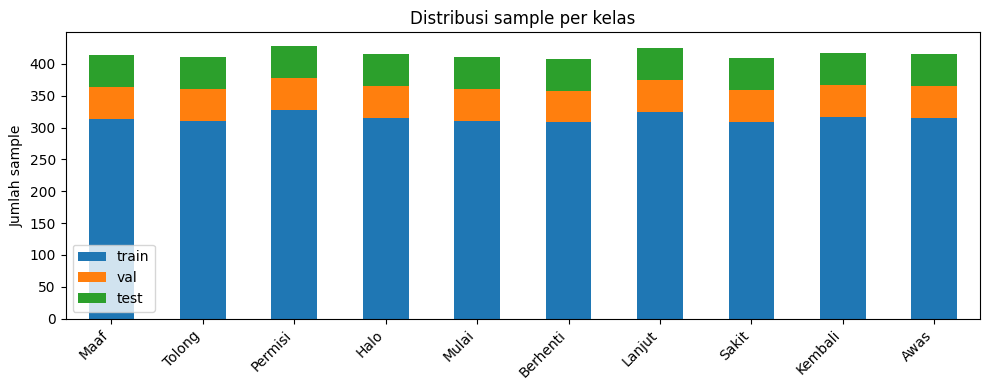

Rasio ketimpangan (kelas terbanyak / kelas tersedikit): 1.05x


In [5]:
# @title 3.4b Distribusi sample per kelas (train/val/test)
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter

def count_per_class(subset, classes):
    counter = Counter()
    for _, label in [subset.dataset.samples[i] if hasattr(subset, "dataset") else subset.samples[i] for i in (subset.indices if hasattr(subset, "indices") else range(len(subset)))]:
        counter[classes[label]] += 1
    return counter

train_counts = count_per_class(train_ds, dataset.classes)
val_counts = count_per_class(val_ds, dataset.classes)
test_counts = count_per_class(test_ds, dataset.classes)

df_dist = pd.DataFrame({
    "train": [train_counts.get(c, 0) for c in dataset.classes],
    "val": [val_counts.get(c, 0) for c in dataset.classes],
    "test": [test_counts.get(c, 0) for c in dataset.classes],
}, index=dataset.classes)
df_dist["total"] = df_dist.sum(axis=1)
display(df_dist)

df_dist[["train", "val", "test"]].plot(kind="bar", stacked=True, figsize=(10, 4))
plt.title("Distribusi sample per kelas")
plt.ylabel("Jumlah sample")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

imbalance_ratio = df_dist["total"].max() / df_dist["total"].min()
print(f"Rasio ketimpangan (kelas terbanyak / kelas tersedikit): {imbalance_ratio:.2f}x")
if imbalance_ratio > 2:
    print("PERINGATAN: ketimpangan cukup besar -- pertimbangkan class weighting (sel 3.4c) atau tambah data kelas minoritas.")


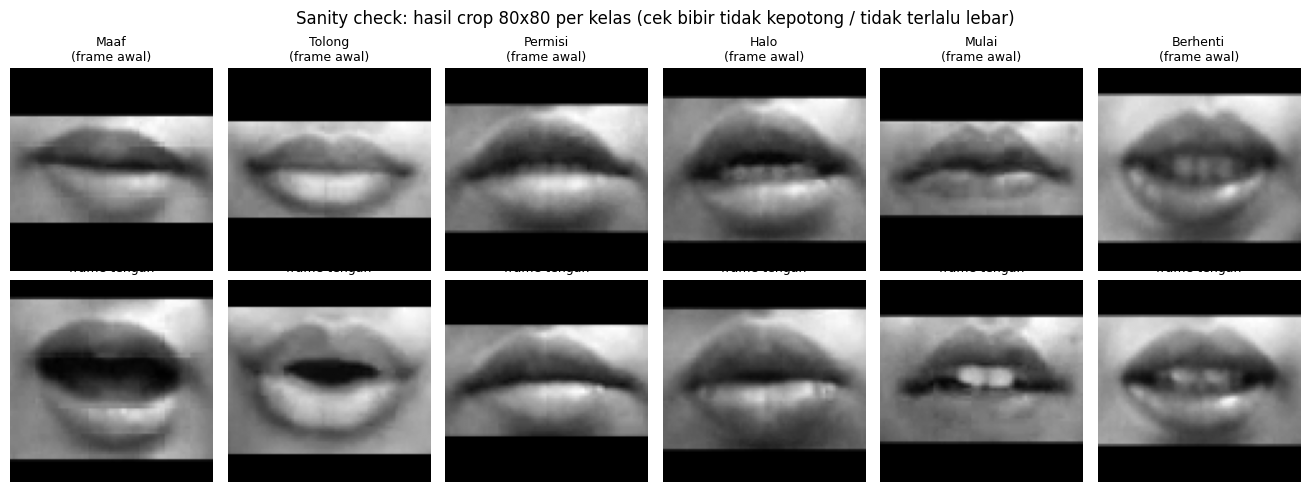

In [8]:
# @title 3.4c Sanity check visual: contoh crop 80x80 per kelas
import numpy as np
import matplotlib.pyplot as plt

n_show = min(6, len(dataset.classes))
fig, axes = plt.subplots(2, n_show, figsize=(2.2 * n_show, 5))

shown_classes = dataset.classes[:n_show]
for col, cls in enumerate(shown_classes):
    label_idx = dataset.class_to_idx[cls]
    sample_path = next(p for p, l in dataset.samples if l == label_idx)
    arr = np.load(sample_path)  # (T, H, W), sudah 0-1

    mid_frame = arr[len(arr) // 2]
    first_frame = arr[0]

    axes[0, col].imshow(first_frame, cmap="gray")
    axes[0, col].set_title(f"{cls}\n(frame awal)", fontsize=9)
    axes[0, col].axis("off")

    axes[1, col].imshow(mid_frame, cmap="gray")
    axes[1, col].set_title("frame tengah", fontsize=9)
    axes[1, col].axis("off")

plt.suptitle("Sanity check: hasil crop 80x80 per kelas (cek bibir tidak kepotong / tidak terlalu lebar)")
plt.tight_layout()
plt.savefig("/content/sanity_check_preprocessing.png", dpi=120)
plt.show()

if CONFIG["USE_WANDB"]:
    import wandb
    if wandb.run is not None:
        wandb.log({"sanity_check_preprocessing": wandb.Image("/content/sanity_check_preprocessing.png")})


In [ ]:
# @title 3.4d (Opsional) Class weighting untuk CrossEntropyLoss
import torch as _torch

class_counts = _torch.tensor([train_counts.get(c, 1) for c in dataset.classes], dtype=_torch.float)
class_weights = class_counts.sum() / (len(dataset.classes) * class_counts)
class_weights = class_weights.to(device)
print("Class weights:", {c: round(w.item(), 3) for c, w in zip(dataset.classes, class_weights)})

CONFIG["USE_CLASS_WEIGHTS"] = True  # set False untuk kembali ke CrossEntropyLoss tanpa weighting


Class weights: {'Maaf': 1.015, 'Tolong': 1.078, 'Permisi': 0.94, 'Halo': 0.958, 'Mulai': 1.029, 'Berhenti': 1.04, 'Lanjut': 0.984, 'Sakit': 1.001, 'Kembali': 0.981, 'Awas': 0.991}


In [10]:
# @title 3.5 Definisi model — LRCN-2Conv dan LRCN-3Conv (Table 2 jurnal)
import torch.nn as nn
import torch.nn.functional as F

class _ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, drop_p=0.4):
        super().__init__()
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2)
        self.drop = nn.Dropout(drop_p)
    def forward(self, x):
        return self.drop(self.pool(F.relu(self.conv(x))))

class _LRCNBase(nn.Module):
    """CNN (TimeDistributed via loop per-frame) + 1 layer LSTM, sesuai Section 3.3 jurnal."""
    def __init__(self, num_classes, feature_maps, input_hw):
        super().__init__()
        self.blocks = nn.ModuleList()
        in_ch = 1
        for out_ch in feature_maps:
            self.blocks.append(_ConvBlock(in_ch, out_ch))
            in_ch = out_ch

        h, w = input_hw
        for _ in feature_maps:
            h, w = h // 2, w // 2
        lstm_input_size = feature_maps[-1] * h * w

        self.flatten = nn.Flatten()
        self.lstm = nn.LSTM(input_size=lstm_input_size, hidden_size=64, batch_first=True)
        self.drop_lstm = nn.Dropout(0.5)
        self.fc = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, 1, T, H, W)
        B, C, T, H, W = x.size()
        x = x.reshape(B * T, C, H, W) # proses dalam satu batch besar (TimeDistributed teroptimasi)
        for block in self.blocks:
            x = block(x)
        x = self.flatten(x)
        x = x.view(B, T, -1) # kembalikan ke format sequence (B, T, F)

        lstm_out, _ = self.lstm(x)
        last = lstm_out[:, -1, :]
        return self.fc(self.drop_lstm(last))

class LRCN2Conv(_LRCNBase):
    def __init__(self, num_classes, input_hw=(80, 80)):
        super().__init__(num_classes, feature_maps=[16, 32], input_hw=input_hw)

class LRCN3Conv(_LRCNBase):
    def __init__(self, num_classes, input_hw=(80, 80)):
        super().__init__(num_classes, feature_maps=[16, 32, 64], input_hw=input_hw)

MODEL_REGISTRY = {"LRCN2Conv": LRCN2Conv, "LRCN3Conv": LRCN3Conv}
print("Model tersedia:", list(MODEL_REGISTRY.keys()))

Model tersedia: ['LRCN2Conv', 'LRCN3Conv']


In [7]:
# @title 3.6 (Opsional) Login Weights & Biases untuk logging training
# 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
if CONFIG["USE_WANDB"]:
    !pip install -q wandb
    import wandb
    wandb.login()

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results


wandb: Enter your choice: 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.


wandb: Paste your API key and hit enter: ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: afnanimadurrosyad911 (afnanimadurrosyad) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


LOSO akan dijalankan untuk 8 fold (speaker): ['1_Natural_Lulu', '2_Pointy_Natural_Sandy', '3_Cupids_Bow_Grace', '4_Thin_Jelly', '5_Unilip_brrr', '6_Bestung_-_intan', '7_Smear_Indra', '8_Glamor_Bella']

FOLD 1/8  |  Held-out (test) speaker: 1_Natural_Lulu
  Train speakers (6): [np.str_('2_Pointy_Natural_Sandy'), np.str_('4_Thin_Jelly'), np.str_('5_Unilip_brrr'), np.str_('6_Bestung_-_intan'), np.str_('7_Smear_Indra'), np.str_('8_Glamor_Bella')]
  Val speakers   (1): [np.str_('3_Cupids_Bow_Grace')]
  Test speaker   : 1_Natural_Lulu
  N train=3115  N val=500  N test=538
  Epoch  1/40 | train_acc=0.100 val_acc=0.126 | train_loss=2.315 val_loss=2.304  <-- best
  Epoch  2/40 | train_acc=0.104 val_acc=0.100 | train_loss=2.306 val_loss=2.304  <-- best
  Epoch  3/40 | train_acc=0.113 val_acc=0.108 | train_loss=2.299 val_loss=2.305
  Epoch  4/40 | train_acc=0.201 val_acc=0.100 | train_loss=2.159 val_loss=2.538
  Epoch  5/40 | train_acc=0.304 val_acc=0.172 | train_loss=1.924 val_loss=2.900
  Epoch

,fold,test_speaker,best_epoch,best_val_loss,test_acc,test_f1_macro,n_train,n_val,n_test
0,1,1_Natural_Lulu,2,2.303565,0.102230,0.018581,3115,500,538
1,2,2_Pointy_Natural_Sandy,1,2.301262,0.134000,0.047682,3153,500,500
2,3,3_Cupids_Bow_Grace,3,2.284458,0.100000,0.018215,3152,501,500
3,4,4_Thin_Jelly,2,2.292400,0.094000,0.017939,3077,576,500
4,5,5_Unilip_brrr,3,2.269028,0.193613,0.110927,3114,538,501
5,6,6_Bestung_-_intan,1,2.354745,0.126736,0.044044,3077,500,576
6,7,7_Smear_Indra,3,2.264748,0.144981,0.086948,3077,538,538
7,8,8_Glamor_Bella,7,2.225222,0.178000,0.101603,3153,500,500



RINGKASAN LOSO
Rata-rata test accuracy : 0.1342  (std=0.0367)
Rata-rata test F1-macro : 0.0557  (std=0.0388)
Rentang akurasi         : 0.0940 - 0.1936


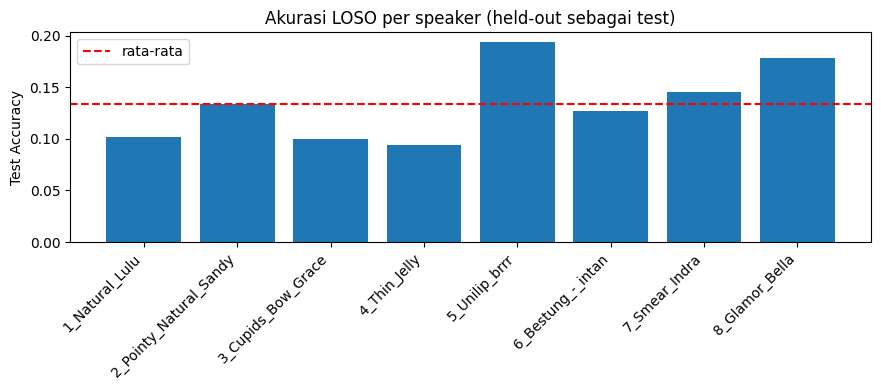

In [11]:
# @title 3.7 Leave-One-Speaker-Out Cross-Validation (LOSO)
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import f1_score

# ------------------------------------------------------------------
# Konfigurasi LOSO
# ------------------------------------------------------------------
LOSO_MAX_EPOCHS = 40      # lebih pendek dari training utama (80) -- LOSO dijalankan
                          # berkali-kali jadi perlu lebih hemat waktu; early stopping
                          # tetap yang menentukan epoch efektif
LOSO_PATIENCE = 8         # early stopping: berhenti kalau val_loss tak membaik
                          # selama N epoch berturut-turut
LOSO_VAL_FRACTION_SPEAKERS = 1  # jumlah speaker (dari sisa train) yang disisihkan
                                 # jadi val internal tiap fold, untuk early stopping

all_speakers = sorted(set(dataset.speakers))
print(f"LOSO akan dijalankan untuk {len(all_speakers)} fold (speaker): {all_speakers}")

fold_results = []
fold_histories = {}

for fold_i, held_out_speaker in enumerate(all_speakers, start=1):
    print("\n" + "=" * 70)
    print(f"FOLD {fold_i}/{len(all_speakers)}  |  Held-out (test) speaker: {held_out_speaker}")
    print("=" * 70)

    speakers_arr = np.array(dataset.speakers)
    labels_arr = np.array([lbl for _, lbl in dataset.samples])

    test_mask = speakers_arr == held_out_speaker
    remaining_speakers = [s for s in all_speakers if s != held_out_speaker]

    # Dari speaker yang TERSISA (bukan held-out), sisihkan sebagian sebagai
    # val internal (untuk early stopping / pilih best epoch), sisanya untuk train.
    remaining_mask = ~test_mask
    remaining_idx = np.where(remaining_mask)[0]
    rem_speakers = speakers_arr[remaining_idx]
    rem_labels = labels_arr[remaining_idx]

    n_val_speakers = max(1, LOSO_VAL_FRACTION_SPEAKERS)
    unique_rem = sorted(set(rem_speakers))
    if len(unique_rem) <= n_val_speakers:
        raise RuntimeError("Terlalu sedikit speaker tersisa untuk membentuk val internal.")

    val_speakers = unique_rem[fold_i % len(unique_rem) : fold_i % len(unique_rem) + n_val_speakers]
    if len(val_speakers) < n_val_speakers:
        val_speakers = unique_rem[: n_val_speakers]  # wrap-around sederhana

    val_mask_local = np.isin(rem_speakers, val_speakers)
    train_idx = remaining_idx[~val_mask_local]
    val_idx = remaining_idx[val_mask_local]
    test_idx = np.where(test_mask)[0]

    print(f"  Train speakers ({len(unique_rem) - len(val_speakers)}): "
          f"{[s for s in unique_rem if s not in val_speakers]}")
    print(f"  Val speakers   ({len(val_speakers)}): {val_speakers}")
    print(f"  Test speaker   : {held_out_speaker}")
    print(f"  N train={len(train_idx)}  N val={len(val_idx)}  N test={len(test_idx)}")

    train_ds_fold = _SubsetByIndices(dataset, train_idx)
    val_ds_fold = _SubsetByIndices(dataset, val_idx)
    test_ds_fold = _SubsetByIndices(dataset, test_idx)

    pin = (device.type == "cuda")
    train_loader_fold = DataLoader(train_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=True, num_workers=2, pin_memory=pin)
    val_loader_fold = DataLoader(val_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)
    test_loader_fold = DataLoader(test_ds_fold, batch_size=CONFIG["BATCH_SIZE"], shuffle=False, num_workers=2, pin_memory=pin)

    # ------------------------------------------------------------------
    # Model & optimizer baru dari NOL tiap fold (tidak boleh reuse weight
    # dari fold sebelumnya, supaya tiap fold benar-benar independen)
    # ------------------------------------------------------------------
    model_fold = LRCN3Conv(num_classes=len(dataset.classes)).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model_fold.parameters(), lr=CONFIG.get("LEARNING_RATE", 0.0005))

    best_val_loss = float("inf")
    best_state = None
    best_epoch = 0
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, LOSO_MAX_EPOCHS + 1):
        # ---- Train ----
        model_fold.train()
        run_loss, run_correct, run_n = 0.0, 0, 0
        for xb, yb in train_loader_fold:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            out = model_fold(xb)
            loss = criterion(out, yb)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * xb.size(0)
            run_correct += (out.argmax(1) == yb).sum().item()
            run_n += xb.size(0)
        train_loss = run_loss / run_n
        train_acc = run_correct / run_n

        # ---- Val ----
        model_fold.eval()
        v_loss, v_correct, v_n = 0.0, 0, 0
        with torch.no_grad():
            for xb, yb in val_loader_fold:
                xb, yb = xb.to(device), yb.to(device)
                out = model_fold(xb)
                loss = criterion(out, yb)
                v_loss += loss.item() * xb.size(0)
                v_correct += (out.argmax(1) == yb).sum().item()
                v_n += xb.size(0)
        val_loss = v_loss / v_n
        val_acc = v_correct / v_n

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        improved = val_loss < best_val_loss
        if improved:
            best_val_loss = val_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model_fold.state_dict())
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        print(f"  Epoch {epoch:2d}/{LOSO_MAX_EPOCHS} | train_acc={train_acc:.3f} val_acc={val_acc:.3f} "
              f"| train_loss={train_loss:.3f} val_loss={val_loss:.3f}"
              f"{'  <-- best' if improved else ''}")

        if epochs_no_improve >= LOSO_PATIENCE:
            print(f"  Early stopping di epoch {epoch} (tidak membaik selama {LOSO_PATIENCE} epoch).")
            break

    # ------------------------------------------------------------------
    # Evaluasi di TEST speaker pakai bobot terbaik (berdasarkan val internal)
    # ------------------------------------------------------------------
    model_fold.load_state_dict(best_state)
    model_fold.eval()
    all_preds, all_true = [], []
    with torch.no_grad():
        for xb, yb in test_loader_fold:
            xb = xb.to(device)
            out = model_fold(xb)
            preds = out.argmax(1).cpu().numpy()
            all_preds.extend(preds)
            all_true.extend(yb.numpy())

    test_acc = np.mean(np.array(all_preds) == np.array(all_true))
    test_f1_macro = f1_score(all_true, all_preds, average="macro")

    print(f"  >> Test ({held_out_speaker}): acc={test_acc:.4f}  f1_macro={test_f1_macro:.4f}  "
          f"(best_epoch={best_epoch}, best_val_loss={best_val_loss:.4f})")

    fold_results.append({
        "fold": fold_i,
        "test_speaker": held_out_speaker,
        "best_epoch": best_epoch,
        "best_val_loss": best_val_loss,
        "test_acc": test_acc,
        "test_f1_macro": test_f1_macro,
        "n_train": len(train_idx),
        "n_val": len(val_idx),
        "n_test": len(test_idx),
    })
    fold_histories[held_out_speaker] = history

# ------------------------------------------------------------------
# Ringkasan hasil LOSO
# ------------------------------------------------------------------
df_loso = pd.DataFrame(fold_results)
display(df_loso)

print("\n" + "=" * 70)
print("RINGKASAN LOSO")
print("=" * 70)
print(f"Rata-rata test accuracy : {df_loso['test_acc'].mean():.4f}  (std={df_loso['test_acc'].std():.4f})")
print(f"Rata-rata test F1-macro : {df_loso['test_f1_macro'].mean():.4f}  (std={df_loso['test_f1_macro'].std():.4f})")
print(f"Rentang akurasi         : {df_loso['test_acc'].min():.4f} - {df_loso['test_acc'].max():.4f}")

# Visualisasi akurasi per speaker (fold)
plt.figure(figsize=(9, 4))
plt.bar(df_loso["test_speaker"], df_loso["test_acc"])
plt.axhline(df_loso["test_acc"].mean(), color="red", linestyle="--", label="rata-rata")
plt.ylabel("Test Accuracy")
plt.title("Akurasi LOSO per speaker (held-out sebagai test)")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# @title 3.7 Training loop (dengan validasi, early stopping, checkpoint terbaik, per-kelas tracking)
import time
import numpy as np
from sklearn.metrics import accuracy_score

def train_model():
    model_cls = MODEL_REGISTRY[CONFIG["MODEL_NAME"]]
    model = model_cls(num_classes=len(dataset.classes)).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=CONFIG["LEARNING_RATE"])

    if CONFIG.get("USE_CLASS_WEIGHTS", False):
        criterion = nn.CrossEntropyLoss(weight=class_weights)
    else:
        criterion = nn.CrossEntropyLoss()

    use_wandb = CONFIG["USE_WANDB"]
    if use_wandb:
        import wandb
        wandb.init(
            project="Lipreading-LRCN",
            name=f"{CONFIG['MODEL_NAME']}-{int(time.time())}-v3",
            config={**CONFIG, "num_classes": len(dataset.classes), "classes": dataset.classes}
        )
        wandb.watch(model, log="all", log_freq=100)

    best_val_acc = 0.0
    patience_counter = 0
    history = []

    for epoch in range(CONFIG["EPOCHS"]):
        model.train()
        total_loss, train_correct, train_total = 0.0, 0, 0

        for batch_idx, (x, y) in enumerate(train_loader):
            x, y = x.to(device, non_blocking=True), y.to(device, non_blocking=True)
            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            pred = logits.argmax(dim=1)
            train_correct += (pred == y).sum().item()
            train_total += y.size(0)

        train_acc = train_correct / train_total
        train_loss = total_loss / len(train_loader)

        # Validasi -- sekalian kumpulkan prediksi per-kelas
        model.eval()
        val_loss, val_correct, val_total = 0.0, 0, 0
        val_preds_all, val_labels_all = [], []
        with torch.no_grad():
            for x, y in val_loader:
                x, y = x.to(device), y.to(device)
                logits = model(x)
                loss = criterion(logits, y)
                val_loss += loss.item()
                pred = logits.argmax(dim=1)
                val_correct += (pred == y).sum().item()
                val_total += y.size(0)
                val_preds_all.extend(pred.cpu().numpy())
                val_labels_all.extend(y.cpu().numpy())

        val_acc = val_correct / val_total
        val_loss = val_loss / len(val_loader)

        # --- Per-class validation accuracy: deteksi dini kalau model collapse ke 1 kelas ---
        val_preds_all = np.array(val_preds_all)
        val_labels_all = np.array(val_labels_all)
        per_class_acc = {}
        collapsed_classes = []
        for class_idx, class_name in enumerate(dataset.classes):
            mask = val_labels_all == class_idx
            if mask.sum() > 0:
                acc_c = (val_preds_all[mask] == class_idx).mean()
                per_class_acc[class_name] = acc_c
                if acc_c == 0.0:
                    collapsed_classes.append(class_name)

        print(f"Epoch {epoch+1:3d}/{CONFIG['EPOCHS']} | "
              f"Train Loss={train_loss:.4f} Acc={train_acc:.2%} | "
              f"Val Loss={val_loss:.4f} Acc={val_acc:.2%}")
        if collapsed_classes:
            print(f"  PERINGATAN: akurasi 0% untuk kelas: {collapsed_classes} -- kemungkinan model collapse/imbalance.")

        log_entry = {
            "epoch": epoch + 1, "train_loss": train_loss, "train_acc": train_acc,
            "val_loss": val_loss, "val_acc": val_acc,
        }
        history.append(log_entry)

        if use_wandb:
            wandb_log = dict(log_entry)
            wandb_log.update({f"val_acc_{c}": a for c, a in per_class_acc.items()})
            wandb.log(wandb_log)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            patience_counter = 0
            torch.save({
                "epoch": epoch,
                "model_name": CONFIG["MODEL_NAME"],
                "model_state": model.state_dict(),
                "optimizer_state": optimizer.state_dict(),
                "val_acc": val_acc,
                "classes": dataset.classes,
                # Simpan konfigurasi preprocessing di dalam checkpoint itu sendiri --
                # supaya script inference/mobile di masa depan bisa BACA formula ini,
                # bukan menyalin manual dan berisiko typo/skew seperti sebelumnya.
                "preprocess_config": {
                    "version": CONFIG.get("PREPROCESS_VERSION"),
                    "target_size": CONFIG["TARGET_SIZE"],
                    "seq_len_word": CONFIG["SEQ_LEN_WORD"],
                    "pad_ratio": CONFIG["PAD_RATIO"],
                    "min_box_size": CONFIG["MIN_BOX_SIZE"],
                },
            }, CONFIG["CHECKPOINT_PATH"])
            print(f"  Model terbaik disimpan (Val Acc = {val_acc:.2%})")
        else:
            patience_counter += 1
            print(f"  Patience: {patience_counter}/{CONFIG['PATIENCE']}")

        if patience_counter >= CONFIG["PATIENCE"]:
            print("Early stopping triggered!")
            break

    if use_wandb:
        wandb.finish()

    return model, history


model, history = train_model()


Epoch   1/80 | Train Loss=2.3137 Acc=9.83% | Val Loss=2.3043 Acc=11.40%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Permisi', 'Halo', 'Berhenti', 'Lanjut', 'Sakit', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 11.40%)
Epoch   2/80 | Train Loss=2.2802 Acc=13.70% | Val Loss=2.3063 Acc=8.60%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Permisi', 'Mulai', 'Berhenti', 'Lanjut', 'Sakit', 'Awas'] -- kemungkinan model collapse/imbalance.
  Patience: 1/8
Epoch   3/80 | Train Loss=2.1237 Acc=20.77% | Val Loss=2.1981 Acc=12.40%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Mulai', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 12.40%)
Epoch   4/80 | Train Loss=1.9022 Acc=29.15% | Val Loss=2.1305 Acc=19.00%
  PERINGATAN: akurasi 0% untuk kelas: ['Maaf', 'Tolong', 'Mulai', 'Sakit', 'Kembali'] -- kemungkinan model collapse/imbalance.
  Model terbaik disimpan (Val Acc = 19.00%)
Epoch   5/8

epoch,▁▁▂▂▃▃▃▄▄▅▅▆▆▆▇▇██
train_acc,▁▁▂▃▄▅▆▆▇▇▇███████
train_loss,██▇▇▆▅▄▃▃▂▂▂▁▁▁▁▁▁
val_acc,▂▁▂▄▃▃▄▅▆█▅▄▆▆▇▇▆▆
val_acc_Awas,█▁▂▄▅▁▂▅▆▇▆▄▃▅▆▅▃▄
val_acc_Berhenti,▁▁▄▃▁▁▁▁▁█▁▁▅▄▄▁▃▄
val_acc_Halo,▁▁▇▇██████████████
val_acc_Kembali,▁█▁▁▁▁▁▁▁▁▁▁▁▁▃▃▁▂
val_acc_Lanjut,▁▁▇▇▁▁▁▁▁▄▁▁▅█▄▄▂▂
val_acc_Maaf,▁▁▁▁▁▃▆▇█▇▃▅▆▄▆▆▆▅
+5,...


In [ ]:
# @title Cetak Rangkuman Training (Run Summary)
import time

# Pastikan training sudah selesai dan variabel 'history' sudah ada
if 'history' in locals() and len(history) > 0:

    # 1. Cari epoch terbaik berdasarkan Val Accuracy tertinggi
    val_accuracies = [log['val_acc'] for log in history]
    best_idx = val_accuracies.index(max(val_accuracies))
    best_log = history[best_idx]
    best_epoch = best_log['epoch']

    # 2. Hitung perkiraan waktu jika ada log waktu (atau gunakan data statis)
    # Catatan: Jika ingin menghitung menit presisi sejak start_time,
    # cell ini harus dijalankan langsung setelah training.

    print("="*60)
    print("                    TRAINING RUN SUMMARY                    ")
    print("="*60)
    print(f"Model Name         : {CONFIG.get('MODEL_NAME', 'Unknown')}")
    print(f"Total Epochs Run   : {len(history)}/{CONFIG.get('EPOCHS', 'N/A')}")
    print(f"Best Epoch         : Epoch {best_epoch}")
    print(f"Checkpoint Saved To: {CONFIG.get('CHECKPOINT_PATH', 'N/A')}")
    print("-"*60)

    print("Final Performance (At Best Epoch):")
    print(f"  - Train Loss     : {best_log['train_loss']:.4f}")
    print(f"  - Train Accuracy : {best_log['train_acc']:.2%}")
    print(f"  - Val Loss       : {best_log['val_loss']:.4f}")
    print(f"  - Val Accuracy   : {best_log['val_acc']:.2%}")
    print("-"*60)

    # 3. Cetak akurasi per kelas dari epoch terbaik
    if 'per_class_acc' in best_log:
        print("Validation Accuracy Per-Class (At Best Epoch):")
        for class_name, acc in best_log['per_class_acc'].items():
            print(f"  * {class_name:<20}: {acc:.2%}")
    elif 'dataset' in locals():
        # Antisipasi jika objek per_class_acc tidak tersimpan di history lama
        print("Validation Accuracy Per-Class (At Best Epoch):")
        print("  [Info] Jalankan ulang training dengan update return history terbaru")

    print("="*60)

else:
    print("❌ Error: Variabel 'history' tidak ditemukan atau training belum berjalan.")

                    TRAINING RUN SUMMARY                    
Model Name         : LRCN3Conv
Total Epochs Run   : 18/80
Best Epoch         : Epoch 10
Checkpoint Saved To: /content/best_model.pth
------------------------------------------------------------
Final Performance (At Best Epoch):
  - Train Loss     : 0.5201
  - Train Accuracy : 83.70%
  - Val Loss       : 2.8827
  - Val Accuracy   : 32.80%
------------------------------------------------------------
Validation Accuracy Per-Class (At Best Epoch):
  [Info] Jalankan ulang training dengan update return history terbaru


### Code untuk membuat plot di bawah belum disesuaikan untuk penggunaan loso diatas, dan masih template default untuk hasil latihan sebuah model dengan non-LOSO.

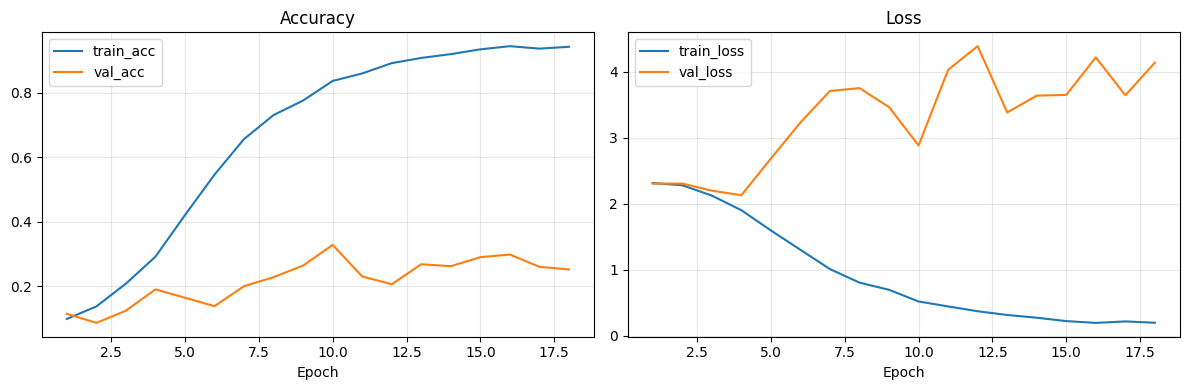

In [ ]:
# @title 3.8 Plot kurva training vs validation accuracy/loss
import matplotlib.pyplot as plt

epochs = [h["epoch"] for h in history]
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, [h["train_acc"] for h in history], label="train_acc")
axes[0].plot(epochs, [h["val_acc"] for h in history], label="val_acc")
axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs, [h["train_loss"] for h in history], label="train_loss")
axes[1].plot(epochs, [h["val_loss"] for h in history], label="val_loss")
axes[1].set_title("Loss"); axes[1].set_xlabel("Epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Bagian 4 — Evaluasi pada Test Set

Menghitung accuracy, precision, recall, F1 score (per kelas + rata-rata), confusion matrix, dan ROC/AUC (one-vs-rest) — sama seperti Table 3, 4, 5 dan Figure 6/7 pada jurnal.

In [ ]:
# @title 4.1 Load model terbaik (checkpoint) untuk evaluasi
best_ckpt = torch.load(CONFIG["CHECKPOINT_PATH"], map_location=device)
eval_model = MODEL_REGISTRY[best_ckpt["model_name"]](num_classes=len(best_ckpt["classes"])).to(device)
eval_model.load_state_dict(best_ckpt["model_state"])
eval_model.eval()
print(f"Model '{best_ckpt['model_name']}' (Val Acc={best_ckpt['val_acc']:.2%}) siap dievaluasi.")

NameError: name 'MODEL_REGISTRY' is not defined

In [ ]:
# @title 4.2 Precision, Recall, F1-score, dan Accuracy pada test set
from sklearn.metrics import classification_report, accuracy_score

all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = eval_model(x)
        pred = logits.argmax(dim=1).cpu().numpy()
        all_preds.extend(pred)
        all_labels.extend(y.numpy())

test_acc = accuracy_score(all_labels, all_preds)
print(f"Test Accuracy: {test_acc:.2%}\n")
print(classification_report(all_labels, all_preds, target_names=dataset.classes, digits=3))
# --- Kirim hasil evaluasi per-kelas ke wandb sebagai Table (kalau masih ada run aktif) ---
if CONFIG["USE_WANDB"]:
    import wandb
    from sklearn.metrics import precision_recall_fscore_support
    if wandb.run is not None:
        precisions, recalls, f1s, supports = precision_recall_fscore_support(
            all_labels, all_preds, labels=range(len(dataset.classes))
        )
        table = wandb.Table(columns=["class", "precision", "recall", "f1", "support"])
        for c, p, r, f, s in zip(dataset.classes, precisions, recalls, f1s, supports):
            table.add_data(c, float(p), float(r), float(f), int(s))
        wandb.log({"test_accuracy": test_acc, "per_class_metrics": table})


Test Accuracy: 95.08%

              precision    recall  f1-score   support

        Maaf      1.000     0.973     0.986        37
      Tolong      1.000     0.950     0.974        40
     Permisi      1.000     0.951     0.975        41
        Halo      0.885     0.958     0.920        24
       Mulai      1.000     0.913     0.955        46
    Berhenti      0.844     0.974     0.905        39
      Lanjut      0.974     0.949     0.961        39
       Sakit      0.919     0.895     0.907        38
     Kembali      0.939     1.000     0.969        31
        Awas      0.938     0.968     0.952        31

    accuracy                          0.951       366
   macro avg      0.950     0.953     0.950       366
weighted avg      0.954     0.951     0.951       366



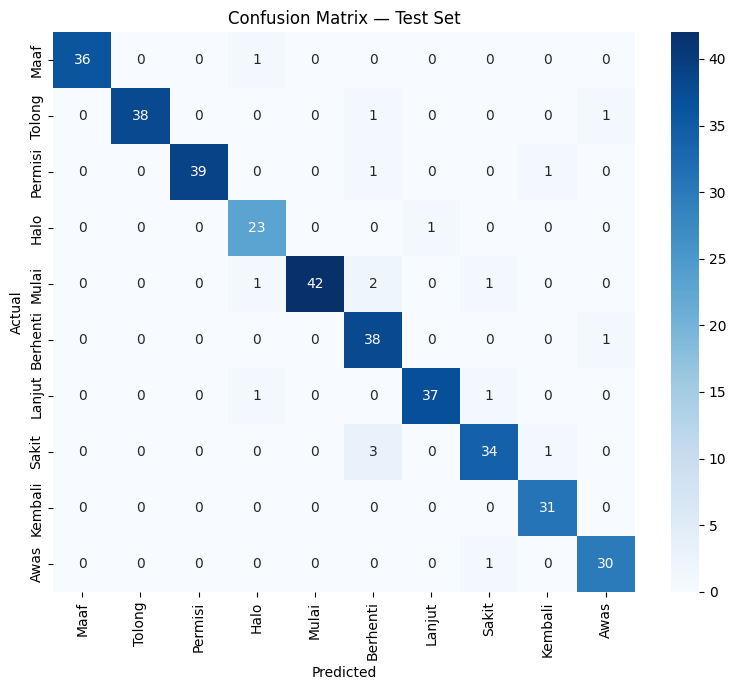

In [ ]:
# @title 4.3 Confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=dataset.classes, yticklabels=dataset.classes)
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()
if CONFIG["USE_WANDB"]:
    import wandb
    if wandb.run is not None:
        plt.savefig("/content/confusion_matrix.png", dpi=120)
        wandb.log({"confusion_matrix_img": wandb.Image("/content/confusion_matrix.png")})


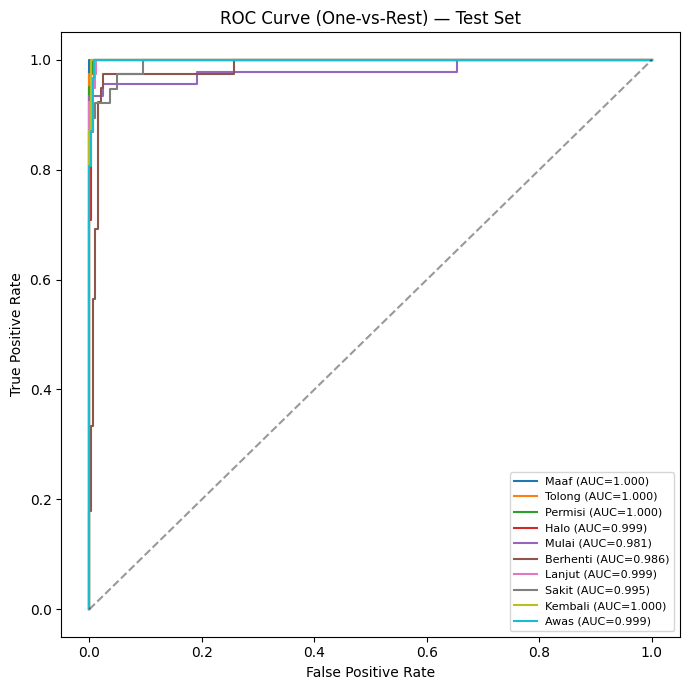

In [ ]:
# @title 4.4 ROC curve & AUC (one-vs-rest), sesuai Figure 6/7 jurnal
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc

all_probs = []
with torch.no_grad():
    for x, y in test_loader:
        x = x.to(device)
        logits = eval_model(x)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        all_probs.extend(probs)
all_probs = np.array(all_probs)

n_classes = len(dataset.classes)
y_bin = label_binarize(all_labels, classes=list(range(n_classes)))

plt.figure(figsize=(7, 7))
for i, cls_name in enumerate(dataset.classes):
    fpr, tpr, _ = roc_curve(y_bin[:, i], all_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{cls_name} (AUC={roc_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.4)
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve (One-vs-Rest) — Test Set")
plt.legend(fontsize=8, loc="lower right")
plt.tight_layout()
plt.show()